In [ ]:
from keras.datasets import imdb

# 전체 데이터셋에서 가장 자주 등장하는 단어 200개만 사용하여 훈련 세트와 테스트 세트를 만듭니다
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=200)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 훈련 세트와 테스트 세트의 입력 데이터의 크기를 확인합니다.
print(train_input.shape, test_input.shape)

(25000,) (25000,)


In [ ]:
# 첫 번째 리뷰의 토큰 개수를 확인합니다
print(len(train_input[0]))

218


In [ ]:
# 두 번째 리뷰의 토큰 개수를 확인합니다.
print(len(train_input[1]))

189


In [ ]:
# 첫 번째 리뷰의 내용을 확인합니다.
print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 173, 36, 2, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 2, 2, 5, 150, 4, 172, 112, 167, 2, 2, 2, 39, 4, 172, 2, 2, 17, 2, 38, 13, 2, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 106, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 2, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 107, 117, 2, 15, 2, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 104, 88, 4, 2, 15, 2, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 2, 22, 21, 134, 2, 26, 2, 5, 144, 30, 2, 18, 51, 36, 28, 2, 92, 25, 104, 4, 2, 65, 16, 38, 2, 88, 12, 16, 2, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [ ]:
# 타깃 데이터를 출력합니다.
print(train_target[:20])

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]


In [ ]:
# 훈련 세트에서 검증 세트를 분리합니다.
from sklearn.model_selection import train_test_split
train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, test_size=0.2, random_state=42)

In [ ]:
# 각 리뷰의 길이를 저장합니다.
import numpy as np
lengths = np.array([len(x) for x in train_input])

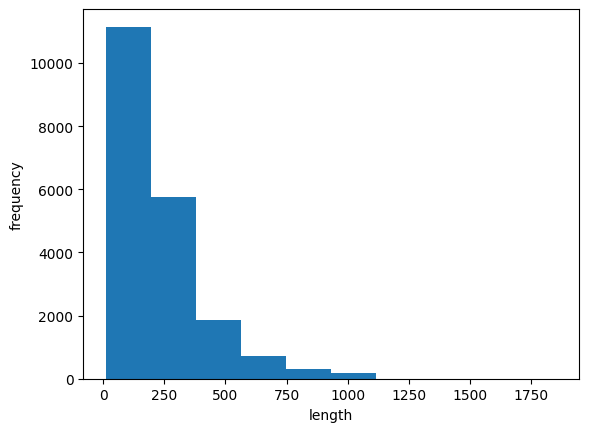

In [ ]:
# 리뷰길이의 분포를 히스토그램으로 나타냅니다.
import matplotlib.pyplot as plt
plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()

In [ ]:
# 훈련 세트의 입력 데이터의 길이를 100으로 맞춥니다.
from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)

In [ ]:
# 훈련 세트의 입력 데이터의 길이가 100으로 잘 맞춰졌는지 확인합니다.
print(train_seq.shape)

(20000, 100)


In [ ]:
# 첫 번째 리뷰를 확인합니다.
print(train_seq[0])

[ 10   4  20   9   2   2   2   5  45   6   2   2  33   2   8   2 142   2
   5   2  17  73  17   2   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12   2  69   2 142  73   2   6
   2   7   2   2 188   2 103  14  31  10  10   2   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10   2 158]


In [ ]:
# 샘플의 앞 부분이 잘리고 남은 샘플에서 맨 뒷 부분의 토큰을 확인합니다.
print(train_input[0][-10:])

[6, 2, 46, 7, 14, 20, 10, 10, 2, 158]


In [ ]:
# 여섯 번째 리뷰를 확인합니다.
print(train_seq[5])

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2   2   2 183  10
  10  13  82  79   4   2  36  71   2   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14   2  56 129   2  10  10  21   2  94   2   2   2   2  11 190
  24   2   2   7  94   2   2  10  10  87   2  34  49   2   7   2   2   2
   2   2   2   2  46  48  64  18   4   2]


In [ ]:
# 검증 세트의 입력 데이터의 길이도 100으로 맞춥니다.
val_seq = pad_sequences(val_input, maxlen=100)

In [ ]:
# 순환 신경망을 이용한 이진 분류 모델을 만듭니다.
import keras

model = keras.Sequential()
model.add(keras.layers.Input(shape=(100, 200)))
model.add(keras.layers.SimpleRNN(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
# 훈련 세트의 입력 데이터를 원-핫 인코딩으로 변환합니다.
train_oh = keras.utils.to_categorical(train_seq)

In [ ]:
# 만들어진 입력 데이터의 크기를 확인합니다.
print(train_oh.shape)

(20000, 100, 200)


In [ ]:
# 첫 번째 리뷰의 첫 번째 단어에 대한 원-핫 인코딩을 확인합니다.
print(train_oh[0][0][:12])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


In [ ]:
# 원-핫 인코딩 벡터에서 1이 하나만 있는지 확인합니다.
print(np.sum(train_oh[0][0]))

1.0


In [ ]:
# 검증 세트의 입력 데이터도 원-핫 인코딩으로 변환합니다.
val_oh = keras.utils.to_categorical(val_seq)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         1,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681 (6.57 KB)

 Trainable params: 1,681 (6.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 모델을 컴파일하고 콜백을 설정한 뒤 모델을 훈련합니다.
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model.fit(train_oh, train_target, epochs=100, batch_size=64, validation_data=(val_oh, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.5264 - loss: 0.6914 - val_accuracy: 0.5624 - val_loss: 0.6811
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5990 - loss: 0.6719 - val_accuracy: 0.6572 - val_loss: 0.6384
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6760 - loss: 0.6128 - val_accuracy: 0.6698 - val_loss: 0.6134
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6971 - loss: 0.5858 - val_accuracy: 0.7040 - val_loss: 0.5811
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7099 - loss: 0.5709 - val_accuracy: 0.7104 - val_loss: 0.5690
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7189 - loss: 0.5607 - val_accuracy: 0.7038 - val_loss: 0.5805
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7225 - loss: 0.5571 - val_accuracy: 0.7170 - val_loss: 0.5626
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7267 - loss: 0.5518 -

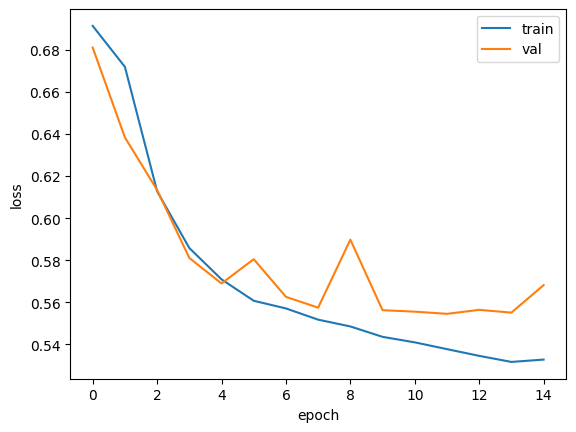

In [ ]:
# 훈련 손실, 검증 손실을 그래프로 그려 훈련 과정을 살펴봅니다.
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [ ]:
# 원-핫 인코딩 전후의 입력 데이터 용량을 비교합니다.
print(train_seq.nbytes, train_oh.nbytes)

8000000 3200000000


In [ ]:
# 전체 데이터셋에서 가장 자주 등장하는 단어 500개만 사용하여 훈련 세트와 테스트 세트를 만듭니다.
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)

train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, test_size=0.2, random_state=42)
train_seq = pad_sequences(train_input, maxlen=100)
val_saq = pad_sequences(val_input, maxlen=100)

In [ ]:
# 순환 신경망 모델을 만듭니다.
model_emb = keras.Sequential()
model_emb.add(keras.layers.Input(shape=(100,)))
model_emb.add(keras.layers.Embedding(500, 16))
model_emb.add(keras.layers.SimpleRNN(8))
model_emb.add(keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
model_emb.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 모델을 컴파일하고 콜백을 설정한 뒤 모델을 훈련합니다.
model_emb.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-embedding-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model_emb.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5997 - loss: 0.6545 - val_accuracy: 0.6860 - val_loss: 0.5995
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7556 - loss: 0.5141 - val_accuracy: 0.6824 - val_loss: 0.6162
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7644 - loss: 0.4985 - val_accuracy: 0.6986 - val_loss: 0.5787
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7693 - loss: 0.4886 - val_accuracy: 0.6860 - val_loss: 0.5853
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7805 - loss: 0.4732 - val_accuracy: 0.6794 - val_loss: 0.6202
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7671 - loss: 0.4886 - val_accuracy: 0.5190 - val_loss: 0.9601


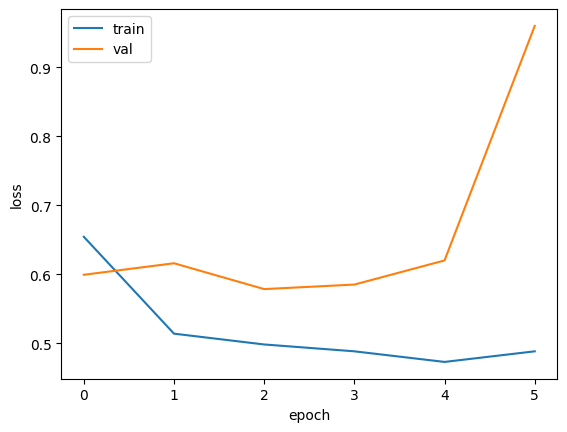

In [ ]:
# 훈련 손실과 검증 손실을 비교합니다.
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [1]:
# 파이토치 버전
# keras.datasets 패키지에서 imdb를 불러옵니다.
from keras.datasets import imdb
from sklearn.model_selection import train_test_split

# imdb에서 자주 사용하는 단어 500개만 사용하여 데이터를 불러옵니다.
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)

# 훈련 세트, 검증 세트를 만듭니다.
train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, test_size=0.2, random_state=42)

# 리뷰 데이터를 100시퀀스로 맞춥니다.
from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# 훈련 세트의 입력 데이터와 타깃 데이터를 각각 출력합니다.
print(train_seq.shape, train_target.shape)

(20000, 100) (20000,)


In [2]:
# 입력 데이터를 파이토치 텐서로 변환합니다.
import torch
train_seq = torch.tensor(train_seq)
val_seq = torch.tensor(val_seq)

In [ ]:
# 타깃 데이터의 데이터 타입을 알아봅니다.
print(train_target.dtype)

int64


In [3]:
# 파이토치 손실함수는 입력으로 실숫값을 기대합니다. 타깃 데이터를 실수형 파이토치 텐서로 변환합니다.
train_target = torch.tensor(train_target, dtype=torch.float32)
val_target = torch.tensor(val_target, dtype=torch.float32)

In [ ]:
# 다시 타깃 데이터의 데이터 타입을 알아봅니다.
print(train_target.dtype)

torch.float32


In [4]:
# 파이토치 모델을 훈련할 때에는 데이터로더를 사용합니다.
from torch.utils.data import DataLoader, TensorDataset

# 데이터로더에 전달할 데이터셋을 만듭니다.
train_dataset = TensorDataset(train_seq, train_target)
val_dataset = TensorDataset(val_seq, val_target)

# 데이터셋을 받아 데이터로더를 만듭니다.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [5]:
# 파이토치에서 nn 모듈을 불러옵니다.
import torch.nn as nn
# nn.Module을 상속받아 순환 신경망 모델 클래스를 정의합니다.
class IMDBRnn(nn.Module):
# 모델에서 사용할 층을 정의합니다.
    def __init__(self):
        super().__init__()
        # 500개의 단어 인덱스를 각각 16차원의 임베딩 벡터로 변환합니다.
        self.embedding = nn.Embedding(500, 16)

        # 16차원의 임베딩 벡터를 받아 8개의 은닉 상태 값을 출력하는 RNN 층을 만듭니다.
        self.rnn = nn.RNN(16, 8, batch_first=True)

        # RNN의 마지막 은닉 상태값을 1개의 이중 분류 출력값 1개로 변환합니다.
        self.dense = nn.Linear(8, 1)

        # 출력값을 0~1사이의 확률로 변환합니다.
        self.sigmoid = nn.Sigmoid()

        # 입력 데이터가 모델을 통과하는 순서를 정의합니다.
    def forward(self, x):
        # 정수 인덱스로 된 단어들을 임베딩 벡터로 변환합니다.
        x = self.embedding(x)

        # 임베딩된 시퀀스를 RNN 층에 전달합니다.
        _, hidden = self.rnn(x)

        # 마지막 은닉 상태를 출력층에 전달합니다.
        outputs = self.dense(hidden[-1])

        # 이진 분류 확률을 반환합니다.
        return self.sigmoid(outputs)

In [6]:
# 순환 신경망 모델 객체를 만듭니다.
model = IMDBRnn()

import torch
# 객체를 GPU에 전달합니다.
device = torch.device('cuda' if torch.cuda.is_available() else cpu)
model.to(device)

IMDBRnn(
  (embedding): Embedding(500, 16)
  (rnn): RNN(16, 8, batch_first=True)
  (dense): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [7]:
import torch.optim as optim

# 모델의 손실함수를 정의 합니다.
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4)

In [13]:
train_hist = []
val_hist = []
patience = 2
best_loss = -1
early_stopping_counter = 0

epochs = 100
# 최대 100번의 에포크 루프를 만듭니다.
for epoch in range(epochs):
    # 모델을 훈련 모드로 전환합니다.
    model.train()

    #모델의 손실값을 저장할 변수를 초기화합니다.
    train_loss = 0

    # 훈련 데이터 로더에서 입력값과 타깃값을 이용하여 루프를 돌립니다.
    for inputs, targets in train_loader:
        # 입력값과 타깃값을 각각 gpu에 전달합니다.
        inputs, targets = inputs.to(device), targets.to(device)

        # 옵티마이저를 0으로 초기화합니다.
        optimizer.zero_grad()

        # 모델에 입력값을 전달하고 이진 분류 값을 저장합니다.
        outputs = model(inputs)

        # 현재 에포크에서의 손실값을 저장합니다.
        loss = criterion(outputs.squeeze(), targets)

        # 현재 에포크에서의 기울기를 계산합니다.
        loss.backward()

        # 현재 에포크에서의 가중치를 갱신합니다.
        optimizer.step()

        # 총 손실값을 구합니다.
        train_loss += loss.item()

    # 모델을 검증 모드로 전환합니다.
    model.eval()

    # 모델의 검증 손실값을 저장할 변수를 초기화합니다.
    val_loss = 0

    # 검증 단계에서는 가중치의 갱신이 필요하지 않기 때문에 기울기 계산을 하지 않도록 합니다.
    with torch.no_grad():
        # 마찬가지로 검증 데이터 로더에서 입력값과 타깃값을 받아 루프를 수행합니다.
        for inputs, targets in val_loader:
            # 입력값과 타깃값을 gpu에 전달합니다.
            inputs, targets = inputs.to(device), targets.to(device)

            # 입력값을 전달하고 이진 분류값을 저장합니다.
            outputs = model(inputs)

            # 손실값을 저장합니다.
            loss = criterion(outputs.squeeze(), targets)

            # 총 검증 손실값을 구합니다.
            val_loss += loss.item()

    # 훈련 손실 점수를 계산합니다.
    train_loss = train_loss / len(train_loader)

    # 검증 손실 점수를 계산합니다.
    val_loss = val_loss / len(val_loader)

    # 데이터 시각화를 위해서 에포크마다 훈련 손실과 검증 손실을 저장합니다.
    train_hist.append(train_loss)
    val_hist.append(val_loss)

    # 에포크 마다 훈련 손실과 검증 손실을 출력합니다.
    print(f'에포크:{epoch+1}', f'훈련 손실:{train_loss:.4f}, 검증 손실:{val_loss:.4f}')

    # 각 에포크마다 손실값의 개선이 설정해둔 patience번만큼 이루어지지 않으면 모델을 조기종료합니다.
    if best_loss == -1 or best_loss > val_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        # 최선의 모델을 저장합니다.
        torch.save(model.state_dict(), 'best_rnn_model.pt')
    else:
        # 개선이 없으면 조기 종료 카운터 변수를 1만큼 증가합니다.
        early_stopping_counter += 1
        # 조기 종료 카운터 변수가 설정한 patience 값보다 커지면 모델을 조기종료합니다.
        if early_stopping_counter >= patience:
            print(f'{epoch+1}번째 에포크에서 조기 종료되었습니다.')
            break

에포크:1 훈련 손실:0.5692, 검증 손실:0.6024
에포크:2 훈련 손실:0.5733, 검증 손실:0.6005
에포크:3 훈련 손실:0.5713, 검증 손실:0.6456
에포크:4 훈련 손실:0.5719, 검증 손실:0.5988
에포크:5 훈련 손실:0.5729, 검증 손실:0.6023
에포크:6 훈련 손실:0.5852, 검증 손실:0.5977
에포크:7 훈련 손실:0.5760, 검증 손실:0.5990
에포크:8 훈련 손실:0.5652, 검증 손실:0.5964
에포크:9 훈련 손실:0.5565, 검증 손실:0.5927
에포크:10 훈련 손실:0.5535, 검증 손실:0.5920
에포크:11 훈련 손실:0.5525, 검증 손실:0.5942
에포크:12 훈련 손실:0.5565, 검증 손실:0.5917
에포크:13 훈련 손실:0.5576, 검증 손실:0.5893
에포크:14 훈련 손실:0.5570, 검증 손실:0.5872
에포크:15 훈련 손실:0.5461, 검증 손실:0.5876
에포크:16 훈련 손실:0.5437, 검증 손실:0.5874
16번째 에포크에서 조기 종료되었습니다.


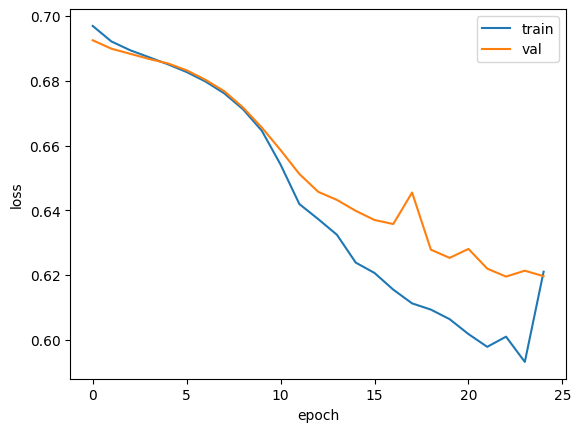

In [9]:
# 훈련 손실과 검증 손실을 시각화합니다.
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [15]:
# 최선의 모델의 가중치를 불러들여 모델을 평가합니다.
model.load_state_dict(torch.load('best_rnn_model.pt', weights_only=True))

# 모델을 평가 모드로 전환합니다.
model.eval()

corrects = 0
# 마찬가지로 가중치를 갱신할 필요가 없기때문에 기울기 연산을 중지합니다.
with torch.no_grad():
    # 입력값과 타깃값을 검증 데이터에서 불러들여 모델 평가를 진행합니다.
    for inputs, targets in val_loader:
        # 입력값과 타깃값을 gpu에 전달합니다.
        inputs, targets = inputs.to(device), targets.to(device)

        # 모델에 입력값을 전달하여 이진분류 출력값을 저장합니다.
        outputs = model(inputs)

        # 모델의 예측값을 0.5를 기준으로 불리언 값으로 변환합니다.
        predicts = outputs > 0.5

        # 변환한 값을 타깃값과 비교하여 정확하게 예측한 시퀀스의 개수를 저장합니다.
        corrects += (predicts.squeeze() == targets).sum().item()

# 저장된 정답 개수를 총 시퀀스의 개수로 나누어 정확도를 계산합니다.
accuracy = corrects / len(val_dataset)

print(f'검증 정확도: {accuracy:.4f}')

검증 정확도: 0.7002
